### Step 1: Import Necessary Libraries

In [1]:
pip install wordcloud nltk textblob

   ---------------------------------------- 0.0/306.1 kB ? eta -:--:--
   --- ----------------------------------- 30.7/306.1 kB 660.6 kB/s eta 0:00:01
   ------------- -------------------------- 102.4/306.1 kB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 306.1/306.1 kB 2.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   --------------------------------------- 625.0/625.0 kB 19.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------  1.5/1.6 MB 49.5 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 24.9 MB/s eta 0:00:00
  Attempting uninstall: nltk
    Found existing installation: nltk 3.8.1
    Uninstalling nltk-3.8.1:
      Successfully uninstalled nltk-3.8.1
Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
import string
import re

### Step 2: Load the CSV File

In [7]:
with open("C:/Users/kaiyang/Desktop/SCMP_Iran.txt", "r", encoding="utf-8") as f:
    article_text = f.read()

df = pd.DataFrame({'doc_id': ['SCMP_article'], 'text': [article_text]})

df.head()

,doc_id,text
0,SCMP_article,US moves to block Iranian ports as Tehran thre...


### Step 3: Preprocess the Text

In [8]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

# Initialize Lemmatizer
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'[^\w\s]', '', text)  # Remove ALL punctuation (including smart quotes)
    
    tokens = word_tokenize(text)  # Tokenize words
    
    tokens = [word for word in tokens if word not in stopwords.words('english')]  # Remove stopwords
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]  # Apply lemmatization
    return " ".join(lemmatized_tokens)

# Apply cleaning function to all titles
df['cleaned_text'] = df['text'].astype(str).apply(clean_text)

# Check cleaned text
print(df[['text', 'cleaned_text']].head())

df.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kaiyang\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kaiyang\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kaiyang\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\kaiyang\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                                text  \
0  US moves to block Iranian ports as Tehran thre...   

                                        cleaned_text  
0  u move block iranian port tehran threatens ret...  


,doc_id,text,cleaned_text
0,SCMP_article,US moves to block Iranian ports as Tehran thre...,u move block iranian port tehran threatens ret...


### Step 4: Generate a Word Cloud

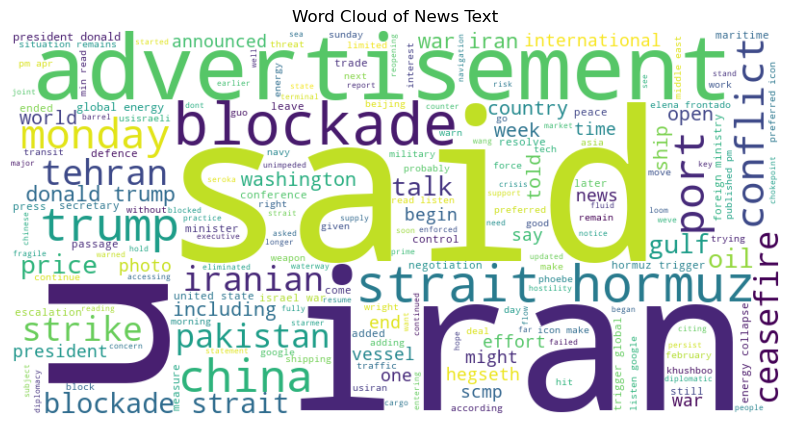

In [9]:
# Combine all titles into a single string
text = " ".join(df['cleaned_text'])

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of News Text")
plt.show()

### Step 5: Sentiment Analysis

In [11]:
def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity  # Returns value between -1 (negative) and 1 (positive)

# Apply sentiment function
df['sentiment'] = df['cleaned_text'].apply(get_sentiment)

# Check results
print(df[['text', 'sentiment']].head())

                                                text  sentiment
0  US moves to block Iranian ports as Tehran thre...   0.054068


### Step 6: Visualize Sentiment Distribution

OptionError: No such keys(s): 'mode.use_inf_as_na'

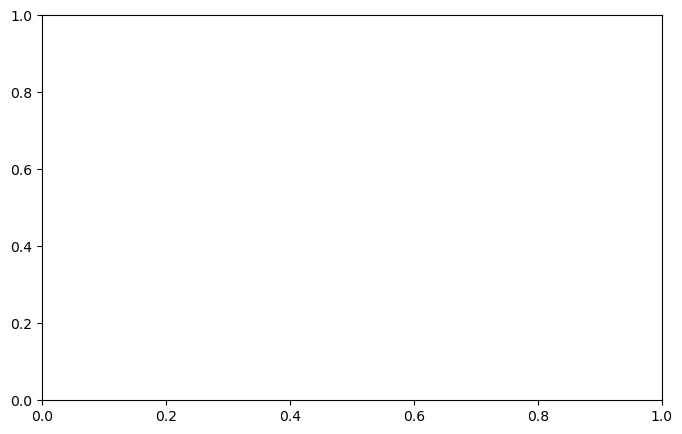

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df['sentiment'], bins=20, kde=True, color='blue')
plt.title("Sentiment Score Distribution")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()

### Step 7: Save Processed Data (Optional)

In [13]:
# df.to_csv("/Users/kaiyang/Desktop/processed_news_data.csv", index=False)

# The End, thank you!